# In-Class Assignment 13

## ZAMS and Evolution on The Main-Sequence

### Learning Objectives

- explore surface stellar properties at ZAMS through the main-sequence
- explore central stellar properties at ZAMS through the main-sequence
- produce and analyze perceived color plots using tulips

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## a. ZAMS and Evolution on the Main-Sequence

### **Individually/ with the person next to you**:

Download, or reuse from a previous class:

* $1 M_\odot$ history data: [M1_default_trimmed_history.data](data/M1_default_trimmed_history.data);

* $5 M_\odot$ history data: [5m_history.data](data/5m_history.data);

* $11 M_\odot$ history data: [11m_subsolar_history.data](data/11m_subsolar_history.data);

Using the all three MESA history data:

1. Compute the index at which the star reaches the zero age main-sequence, in MESA this is defined as 

```
 L_nuc_burn_total >= s% L_phot*s% Lnuc_div_L_zams_limit
```

where a value `Lnuc_div_L_zams_limit=0.99`.


2. Compute the index at which the star reaches the _terminal_ age main-sequence, that is when it has depleted or reached a central value of about $X_{\rm{c}}({^{1}\rm{H}})\lesssim 10^{-3}$.


3. Plot the an HR diagram x-axis ($\textrm{log}T_{\rm{eff.}}$) versus y axis ($\textrm{log}L$) only over the range from idx ZAMS to idx TAMS. [Reference for indexing in Python](https://www.geeksforgeeks.org/python/how-to-index-and-slice-strings-in-python/).

> Hint: the sytax would be like [one_m_ZAMS_idx : one_m_TAMS_idx] at the end of each array you plot. 

> Hint:  Compare with Pols Figure 9.9.

In [2]:
# load data with pandas
one_m_ms_history = pd.read_csv('data/M1_default_trimmed_history.data',sep=r'\s+',header=4)
five_m_ms_history = pd.read_csv('data/5m_history.data',sep=r'\s+',header=4)
eleven_m_ms_history = pd.read_csv('data/11m_subsolar_history.data',sep=r'\s+',header=4)
#list(one_m_ms_history)

In [3]:
Lnuc_div_L_zams_limit = 0.99
center_h1_lim = 1e-3


one_m_ms_history_logTeff = one_m_ms_history['log_Teff'] # log Teff
one_m_ms_history_logL = one_m_ms_history['log_L'] # log L
one_m_ms_history_logLH = one_m_ms_history['log_LH'] # log LH (log Lnuc)
one_m_ms_history_h1 = one_m_ms_history['center_h1'] # central h1 mass fraction

one_m_ZAMS_idx_array = np.where(one_m_ms_history_logLH > Lnuc_div_L_zams_limit * one_m_ms_history_logL)[0]
one_m_ZAMS_idx = one_m_ZAMS_idx_array[0]
one_m_TAMS_idx_array = np.where(one_m_ms_history_h1 < center_h1_lim)[0]
one_m_TAMS_idx = one_m_TAMS_idx_array[0]
#print(one_m_ZAMS_idx,one_m_TAMS_idx)

five_m_ms_history_logTeff = five_m_ms_history['log_Teff'] # log Teff
five_m_ms_history_logL = five_m_ms_history['log_L'] # log L
five_m_ms_history_logLH = five_m_ms_history['log_LH'] # log LH (log Lnuc)
five_m_ms_history_h1 = five_m_ms_history['center_h1'] # central h1 mass fraction

five_m_ZAMS_idx_array = np.where(five_m_ms_history_logLH > Lnuc_div_L_zams_limit * five_m_ms_history_logL)[0]
five_m_ZAMS_idx = five_m_ZAMS_idx_array[0]
five_m_TAMS_idx_array = np.where(five_m_ms_history_h1 < center_h1_lim)[0]
five_m_TAMS_idx = five_m_TAMS_idx_array[0]
#print(five_m_ZAMS_idx,five_m_TAMS_idx)

eleven_m_ms_history_logTeff = eleven_m_ms_history['log_Teff'] # log Teff
eleven_m_ms_history_logL = eleven_m_ms_history['log_L'] # log L
eleven_m_ms_history_logLH = eleven_m_ms_history['log_LH'] # log LH (log Lnuc)
eleven_m_ms_history_h1 = eleven_m_ms_history['center_h1'] # central h1 mass fraction

eleven_m_ZAMS_idx_array = np.where(eleven_m_ms_history_logLH > Lnuc_div_L_zams_limit * eleven_m_ms_history_logL)[0]
eleven_m_ZAMS_idx = eleven_m_ZAMS_idx_array[0]
eleven_m_TAMS_idx_array = np.where(eleven_m_ms_history_h1 < center_h1_lim)[0]
eleven_m_TAMS_idx = eleven_m_TAMS_idx_array[0]
#print(eleven_m_ZAMS_idx,eleven_m_TAMS_idx)

Text(0, 0.5, '$\\rm{log}~L \\ (L_{\\odot})$')

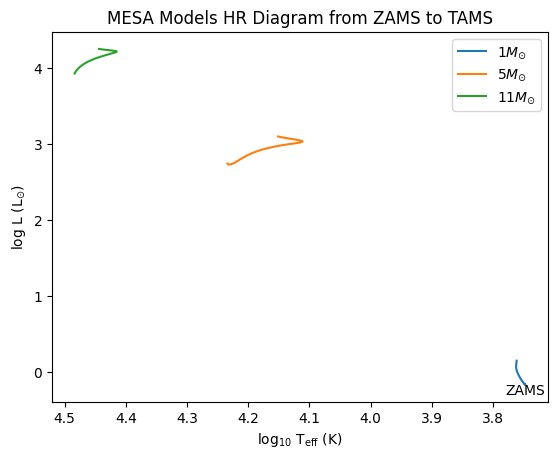

In [4]:
## 1-2 result here
plt.title('MESA Models HR Diagram from ZAMS to TAMS')

plt.plot(one_m_ms_history_logTeff[one_m_ZAMS_idx:one_m_TAMS_idx],
         one_m_ms_history_logL[one_m_ZAMS_idx:one_m_TAMS_idx],label=r'$1M_{\odot}$')

plt.plot(five_m_ms_history_logTeff[five_m_ZAMS_idx:five_m_TAMS_idx],
         five_m_ms_history_logL[five_m_ZAMS_idx:five_m_TAMS_idx],label=r'$5M_{\odot}$')

plt.plot(eleven_m_ms_history_logTeff[eleven_m_ZAMS_idx:eleven_m_TAMS_idx],
         eleven_m_ms_history_logL[eleven_m_ZAMS_idx:eleven_m_TAMS_idx],label=r'$11M_{\odot}$')


plt.annotate('ZAMS', xy=(3.78, -0.3),xycoords='data')


plt.gca().invert_xaxis()

plt.legend()
plt.xlabel(r'$\rm{log}_{10}~T_{\rm{eff}}~(\rm{K})$')
plt.ylabel(r'$\rm{log}~L \ (L_{\odot})$')

### **With your larger group, try to answer the following**:

5. Describe the qualitative properties of the 3 stellar models while on the main-sequence.

> All stars become more luminious (increase) and grow larger at the surface and become cooler (lower Teff).

6. Why might the change in radius of the 1 Msun model be modest in comparison to the more massive models?

> Hint: Pols Eqn 9.14.

> The more massive models undergo CNO burning with a higher temperature dependence, as such in order for the core and overlying envelope to maintain HE. Due to ideal gas, $\mu$ increase requires central pressure decrease which is only possible if envelope pressure decreases, achieved by the expansion of the stellar envelope. 

7. Why do the more massive star models go to the right on the HRD before turning left (blueward) before hydrogen depletion? What is happening to the core at this time?

> As the fuel, H, is depleted, the energy source is reduced and now more energy is emitted the the surface, to maintain HE, the core must begin to contract the raise the central temperature. As the core contracts, the surface Teff again increase and the star moves blueward. 

8. The core at its blueist point in the HRD, eventually reaches a new hydrostatic equilibrium with the now H depleted core and a new energy source (prior to Core He Burning.). What might be this energy source be and where is it located?

> The core eventually contracts to now form a thick H-shell surrounding the He-core that is in HSE and later moves the star redward on the HRD until Core He burning. 


## b. Structure Evolution on the Main-Sequence

### **Individually/ with the person next to you**:

Using only the $5M_{\odot}$ MESA history data:

1. Plot the central mean molecular weight (`mu`), $\rho$, $T$, $R$ at the surface, and $L_{\rm{nuc.,H}}$ as a function of model number, all normalized by their values at ZAMS.

> Hint: the sytax would be like [one_m_ZAMS_idx : one_m_TAMS_idx] at the end of each array you plot. 

> Hint:  Compare with Pols Figure 9.9 

In [5]:
five_m_ms_history_center_P_norm = 10**(five_m_ms_history['log_center_P'])/10**(five_m_ms_history['log_center_P'][five_m_ZAMS_idx]) # central P
five_m_ms_history_center_T_norm = 10**(five_m_ms_history['log_center_T'])/10**(five_m_ms_history['log_center_T'][five_m_ZAMS_idx]) # central T
five_m_ms_history_surface_R_norm = 10**(five_m_ms_history['log_R'])/10**(five_m_ms_history['log_R'][five_m_ZAMS_idx]) # surface R (Rsun)
five_m_ms_history_center_mu_norm = five_m_ms_history['center_mu']/five_m_ms_history['center_mu'][five_m_ZAMS_idx] # central mu
five_m_ms_history_model_number = five_m_ms_history['model_number'] # model_number
five_m_ms_history_log_LH_norm = 10**(five_m_ms_history['log_LH'])/10**(five_m_ms_history['log_LH'][five_m_ZAMS_idx]) # log_LH


Text(0, 0.5, '$\\rm{Variable \\ Normalized \\ by \\ ZAMS \\ Value}$')

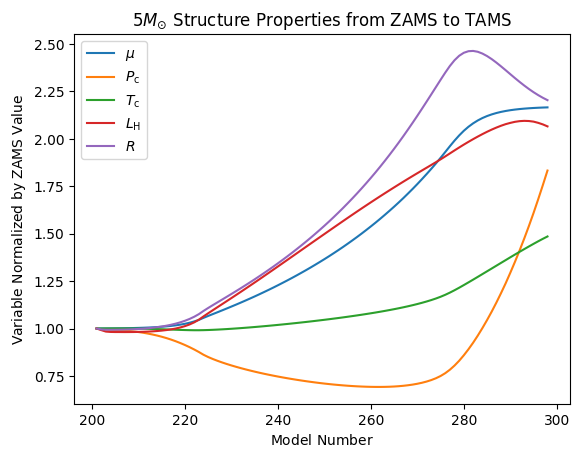

In [6]:
## 1-2 result here
plt.title('5$M_{\odot}$ Structure Properties from ZAMS to TAMS')

plt.plot(five_m_ms_history_model_number[five_m_ZAMS_idx:five_m_TAMS_idx],
         five_m_ms_history_center_mu_norm[five_m_ZAMS_idx:five_m_TAMS_idx],
         label=r'$\mu$')

plt.plot(five_m_ms_history_model_number[five_m_ZAMS_idx:five_m_TAMS_idx],
         five_m_ms_history_center_P_norm[five_m_ZAMS_idx:five_m_TAMS_idx],
         label=r'$P_{\rm{c}}$')

plt.plot(five_m_ms_history_model_number[five_m_ZAMS_idx:five_m_TAMS_idx],
         five_m_ms_history_center_T_norm[five_m_ZAMS_idx:five_m_TAMS_idx],
         label=r'$T_{\rm{c}}$')

plt.plot(five_m_ms_history_model_number[five_m_ZAMS_idx:five_m_TAMS_idx],
         five_m_ms_history_log_LH_norm[five_m_ZAMS_idx:five_m_TAMS_idx],
         label=r'$L_{\rm{H}}$')

plt.plot(five_m_ms_history_model_number[five_m_ZAMS_idx:five_m_TAMS_idx],
         five_m_ms_history_surface_R_norm[five_m_ZAMS_idx:five_m_TAMS_idx],
         label=r'$R$')

plt.xlim()

plt.legend()
plt.xlabel(r'$\rm{Model \ Number}$')
plt.ylabel(r'$\rm{Variable \ Normalized \ by \ ZAMS \ Value}$')

### **With your larger group, try to answer the following**:

2. Describe in a few sentences the qualitative properties of the core (or central) values on the main-sequence.

> The central pressure decreases on the MS while the T, L, mean molecular weight over time.

3. The radius at the surface peaks at some point on the MS, does this relate to your result from 7a. If so, how? What is happening to mu at this inflection point?

> Our answer from 7a, made an argument of the radius reaching a max, Teff reaching a minimum and this is shown here in this plot as well. 

4. What is happening to mu at this inflection point of the radius?

> Mu is flattening out and reaching a constant value. This suggests the burning source has processed all the H and HSE is disturbed and must be obtained in a new configuration absent this burning source. 

5. Eventually the star with proceed with a inert He core overlaid with a thick H-burning shell. What might you expect that to to mean for the surface radius? What trajectory would the star take when this shell is formed?

> When the thick H-shell is formed the star will grow in radius and traverse redward to lower Teff as the core continues to contract and grow in T and density until the conditions of He-burning are met. 

## c. Perceived color diagram on the MS

```note
The color is determined using the colorpy package, which approximates the spectrum of a star using its effective temperature. According to the 1931 color matching functions of the Commission Internationale de l’Eclairage, this spectrum is converted to the approximate RGB color the human eye will perceive.
```

### **Individually/ with the person next to you**:

1. In your current working directory create a folder called `LOGS`.

1. Copy your `5m_history.data` into this directory and rename it `history.data`. It will look in this directory for a file called `history.data`.

3. Create your data object for analysis using `mesaPlot`: 

```
m5 = mp.MESA()
```

4. Load the history data using this object:

```
m5.loadHistory(filename_in=`YOUR_PATH_NAME`+ "history.data")
```

5. Now, using `tulips` to produce an `perceived_color` [plot](https://astro-tulips.readthedocs.io/en/latest/perceived_color_diagram.html) using your history data. It will create a series of these plots based on your defined step size `N`.

In [7]:
# only uncomment if you were able to successfully install
import tulips

# note the capital `P`
import mesaPlot as mp

In [8]:
# Specify  directory of MESA model
#SINGLE_M11_DIR = "../../tulips/MESA_DIR_EXAMPLE/"
SINGLE_M5_DIR = "./data/LOGS/"

m5 = mp.MESA()
m5.loadHistory(filename_in=SINGLE_M5_DIR + "history.data")

idx_low = 0
idx_upper = 400 
N = 2 

  0%|          | 0/200 [00:00<?, ?it/s]

Creating animation


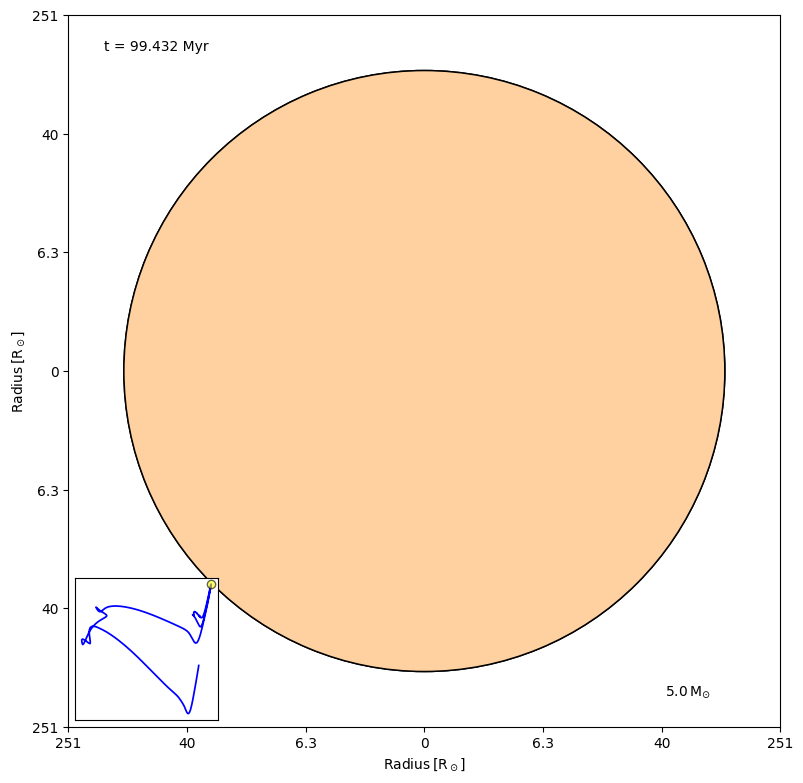

In [9]:
tulips.perceived_color(m5, time_ind=(idx_low, idx_upper , N), 
                       fps=10, output_fname="perceived_color", fig_size=(10, 8))
plt.show()

In [10]:
from IPython.display import Video

Video("perceived_color.mp4", embed=True, width=700, height=600)

### **With your larger group, try to answer the following**:

5. Using the perceived color plot, discuss and identify the impact on the color of the star once the thick H-shell has been formed and its evolution in the HRD. That is, over which frames/time in the visualzation is the star undergoing thick H-shell burning.

> Hint: Start by idenifying the ZAMS and TAMS (including when our R reaches a max before contracting again).

> This star is undergoing thick H-shell burning from about 98 to 100 Myr and is becoming larger in radius, more red, and cooler at the surface prior core CHeB. This relatively short period is known as the _[Hertzsprung gap](https://en.wikipedia.org/wiki/Hertzsprung_gap)_. Shell then becomes thin, star ascends RGB, and opacity increases in envelope becoming convective and leading to first dredge up. 